## Importing modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Importing from files

In [2]:
import sys
import os

# Move up to the parent directory of 'notebookDir'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Now import the module
from axion_production.muon_scattering.muon_scattering_analysis import MuonScatteringModel

In [3]:
file_path = '../Maxim-data/Distributions_fa_mu_scat.dat'  # Set the correct file path
muonScattering = MuonScatteringModel(file_path)

## Checking First Interpolation
In this step, we retrieve input data for different distributions and their interpolations (`f(q)`, `f(q) * q^1`, `f(q) * q^2`, `f(q) * q^3`). The goal is to compare raw input values with their interpolated results. It is crucial to mention that the true input data comes from the distribution `f(q) * q^2`, which originates from the Maxim code. This code calculates the real axion distribution in a specific production process, where axions are produced via muon scattering:

$$ \mu + \mu \rightarrow a + \mu + \mu $$

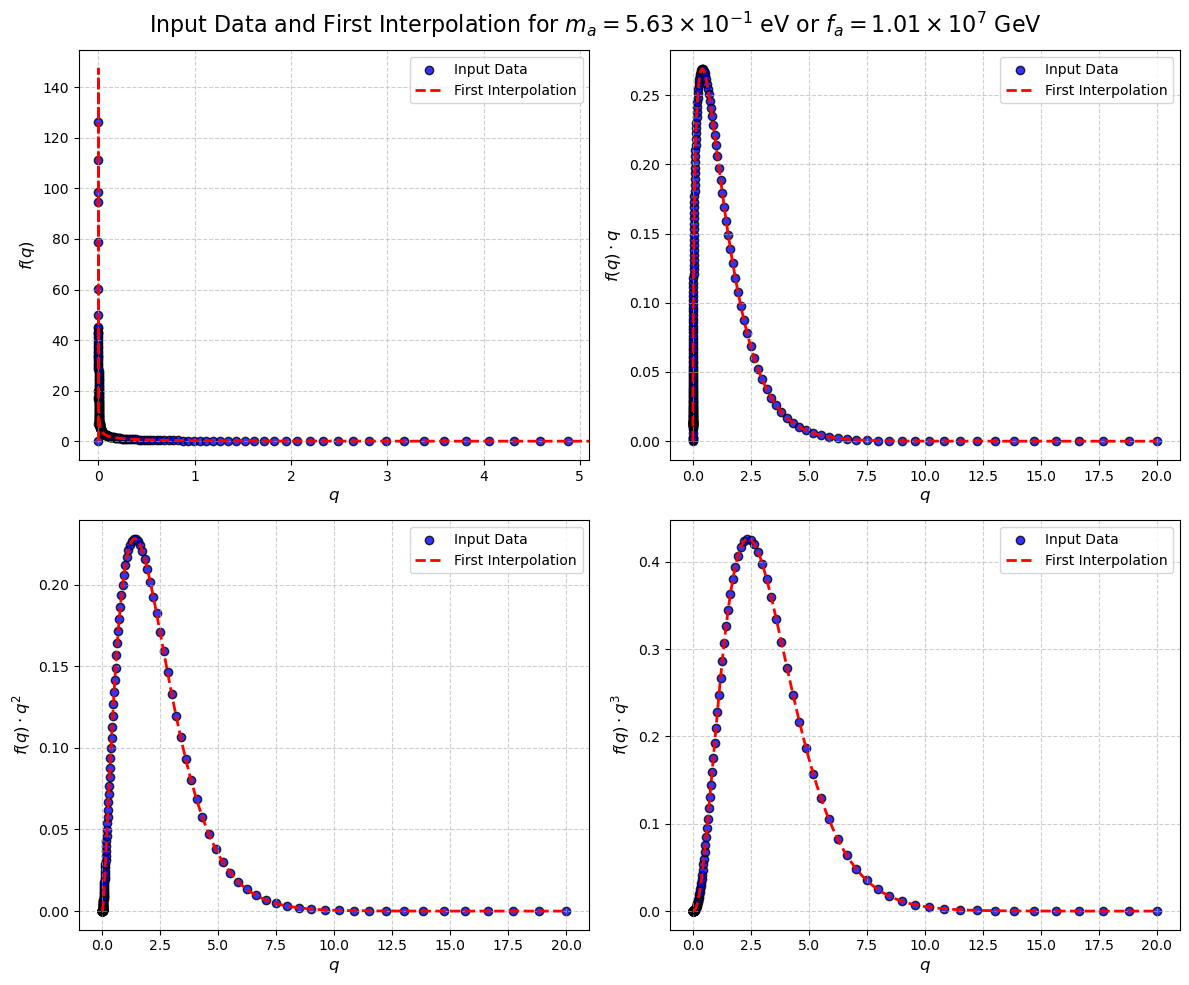

In [4]:
# Retrieve data
index = 100
axion_mass = muonScattering.get_axion_masses()[index]
decay_constant = muonScattering.calculate_fa(axion_mass)
input_dist_q0 = muonScattering.get_input_distribution(dist="f(q)")
input_dist_q1 = muonScattering.get_input_distribution(dist="f(q)_q1")
input_dist_q2 = muonScattering.get_input_distribution(dist="f(q)_q2")
input_dist_q3 = muonScattering.get_input_distribution(dist="f(q)_q3")
input_q_arr = muonScattering.get_comoving_momenta()

# Convert to scientific notation and extract base & exponent
axion_mass_base, axion_mass_exp = f"{axion_mass:.2e}".split("e")
decay_constant_base, decay_constant_exp = f"{decay_constant:.2e}".split("e")
# Format with integer exponents (ensuring proper LaTeX)
axion_mass_formatted = rf"{float(axion_mass_base):.2f} \times 10^{{{int(axion_mass_exp)}}}"
decay_constant_formatted = rf"{float(decay_constant_base):.2f} \times 10^{{{int(decay_constant_exp)}}}"

# First interpolation data
interp1_q_arr = np.logspace(np.log10(1e-4), np.log10(20), 500, base=10.0)
interp1_dist_q0 = muonScattering.get_interpolated_distribution(dist="f(q)")
interp1_dist_q1 = muonScattering.get_interpolated_distribution(dist="f(q)_q1")
interp1_dist_q2 = muonScattering.get_interpolated_distribution(dist="f(q)_q2")
interp1_dist_q3 = muonScattering.get_interpolated_distribution(dist="f(q)_q3")

# Set up figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(rf"Input Data and First Interpolation for $m_a = {axion_mass_formatted}$ eV or " 
             rf"$f_a = {decay_constant_formatted}$ GeV", fontsize=16)

# Define plot titles and datasets
titles = [r'$f(q)$', r'$f(q) \cdot q$', 
          r'$f(q) \cdot q^2$', r'$f(q) \cdot q^3$']
input_dists = [input_dist_q0, input_dist_q1, input_dist_q2, input_dist_q3]
interp_dists = [interp1_dist_q0, interp1_dist_q1, interp1_dist_q2, interp1_dist_q3]

# Loop through subplots
for i, ax in enumerate(axes.flat):
    # Plot input data points
    ax.scatter(input_q_arr, input_dists[i][index], 
               color='blue', marker='o', edgecolors='black', 
               alpha=0.8, label='Input Data')

    # Plot first interpolation
    ax.plot(interp1_q_arr, interp_dists[i][index](interp1_q_arr), 
            linestyle='--', linewidth=2, color='red', 
            label='First Interpolation')

    # Labels and title
    ax.set_xlabel(r'$q$', fontsize=12)
    ax.set_ylabel(titles[i], fontsize=12)
    # ax.set_title(titles[i], fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

    if i == 0:
        ax.set_xlim(left=-0.2,right=5.1)

# Adjust layout
plt.tight_layout()
plt.show()

## Checking Second Interpolation

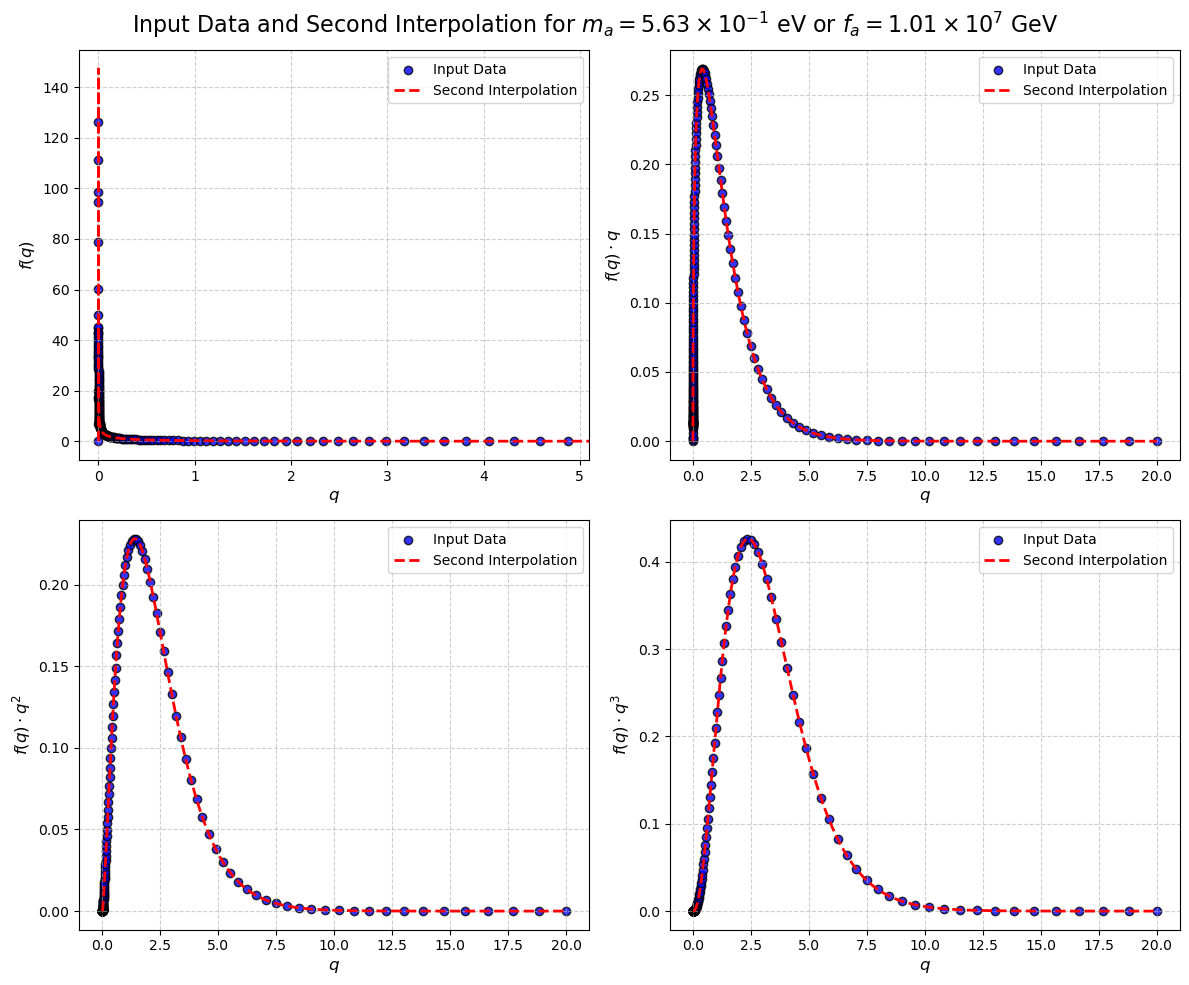

In [5]:
# Retrieve data
index = 100
axion_mass = muonScattering.get_axion_masses()[index]
decay_constant = muonScattering.calculate_fa(axion_mass)
input_dist_q0 = muonScattering.get_input_distribution(dist="f(q)")
input_dist_q1 = muonScattering.get_input_distribution(dist="f(q)_q1")
input_dist_q2 = muonScattering.get_input_distribution(dist="f(q)_q2")
input_dist_q3 = muonScattering.get_input_distribution(dist="f(q)_q3")
input_q_arr = muonScattering.get_comoving_momenta()

# Convert to scientific notation and extract base & exponent
axion_mass_base, axion_mass_exp = f"{axion_mass:.2e}".split("e")
decay_constant_base, decay_constant_exp = f"{decay_constant:.2e}".split("e")
# Format with integer exponents (ensuring proper LaTeX)
axion_mass_formatted = rf"{float(axion_mass_base):.2f} \times 10^{{{int(axion_mass_exp)}}}"
decay_constant_formatted = rf"{float(decay_constant_base):.2f} \times 10^{{{int(decay_constant_exp)}}}"

# --- SECOND INTERPOLATION
interp2_q_arr = np.logspace(np.log10(1e-4), np.log10(20), 500, base=10.0)
second_interpolation_q3 = muonScattering.generate_second_interpolation(axion_mass, interp2_q_arr, dist="f(q)_q3")
second_interpolation_q2 = muonScattering.generate_second_interpolation(axion_mass, interp2_q_arr, dist="f(q)_q2")
second_interpolation_q1 = muonScattering.generate_second_interpolation(axion_mass, interp2_q_arr, dist="f(q)_q1")
second_interpolation_q0 = muonScattering.generate_second_interpolation(axion_mass, interp2_q_arr, dist="f(q)")

# --- PLOT PART
# Set up figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(rf"Input Data and Second Interpolation for $m_a = {axion_mass_formatted}$ eV or " 
             rf"$f_a = {decay_constant_formatted}$ GeV", fontsize=16)

# Define plot titles and datasets
titles = [r'$f(q)$', r'$f(q) \cdot q$', 
          r'$f(q) \cdot q^2$', r'$f(q) \cdot q^3$']
input_dists = [input_dist_q0, input_dist_q1, input_dist_q2, input_dist_q3]
interp2_dists = [second_interpolation_q0, second_interpolation_q1, second_interpolation_q2, second_interpolation_q3]

# Loop through subplots
for i, ax in enumerate(axes.flat):
    # Plot input data points
    ax.scatter(input_q_arr, input_dists[i][index], 
               color='blue', marker='o', edgecolors='black', 
               alpha=0.8, label='Input Data')

    # Plot first interpolation
    ax.plot(interp1_q_arr, interp_dists[i][index](interp1_q_arr), 
            linestyle='--', linewidth=2, color='red', 
            label='Second Interpolation')

    # Labels and title
    ax.set_xlabel(r'$q$', fontsize=12)
    ax.set_ylabel(titles[i], fontsize=12)
    # ax.set_title(titles[i], fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

    if i == 0:
        ax.set_xlim(left=-0.2,right=5.1)

# Adjust layout
plt.tight_layout()
plt.show()